In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

c:\Users\Kim_W\BI_Assignment\BI_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Predicting weather a flight will arrive more than 15 minutes late

In [2]:
data_1993 = pd.read_csv('data_1993_2.csv', low_memory = False)
data_1993

,Unnamed: 0,CRSElapsedTime,DepDelay,Origin,Dest,Distance,time_of_day_CRSDepTime,time_of_day_CRSArrTime,Weekend,Season,Delay
0,0,77,0.0,EWR,BUF,282.0,2,3,0,1,1
1,1,77,-3.0,EWR,BUF,282.0,2,3,1,1,0
2,2,77,8.0,EWR,BUF,282.0,2,3,1,1,0
3,3,131,8.0,MCO,PIT,834.0,3,4,0,1,0
4,4,131,7.0,MCO,PIT,834.0,3,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
2105417,2105417,60,-3.0,EWR,BWI,169.0,2,2,0,1,0
2105418,2105418,60,0.0,EWR,BWI,169.0,2,2,0,1,0
2105419,2105419,60,3.0,EWR,BWI,169.0,2,2,0,1,0
2105420,2105420,60,-4.0,EWR,BWI,169.0,2,2,0,1,0


In [3]:
data_1993 = data_1993.drop(['Unnamed: 0'], axis=1)

## 1. Training, Test & Validation Set

In [4]:
X_1993 = data_1993.drop(columns = ['Delay', 'Weekend', 'Season'], axis=1)
y_1993 = data_1993['Delay']

In [5]:
rus = RandomUnderSampler(sampling_strategy=0.7, random_state=42)
X_1993_res, y_1993_res = rus.fit_resample(X_1993, y_1993)

In [6]:
categorical_cols_1993 = X_1993_res.select_dtypes(include='object').columns

numerical_cols_1993 = X_1993_res.select_dtypes(exclude='object').columns

In [7]:
X_1993_categorical_encoded = pd.get_dummies(X_1993_res[categorical_cols_1993], drop_first=True, dummy_na=False)

X_1993_processed = pd.concat([X_1993_res[numerical_cols_1993], X_1993_categorical_encoded], axis=1)

In [8]:
Scaler_1993 = StandardScaler()
X_1993_scaled = Scaler_1993.fit_transform(X_1993_processed)

In [9]:
X_train_1993, X_temp_1993, y_train_1993, y_temp_1993 = train_test_split(X_1993_scaled, y_1993_res, test_size=0.30, random_state=42, stratify=y_1993_res)
X_val_1993, X_test_1993, y_val_1993, y_test_1993 = train_test_split(X_temp_1993, y_temp_1993, test_size=0.50, random_state=42, stratify=y_temp_1993)

In [10]:
print("Data_1993 preparation and splitting complete.")
print(f"X_train_1993 shape: {X_train_1993.shape}")
print(f"X_val_1993 shape: {X_val_1993.shape}")
print(f"X_test_1993 shape: {X_test_1993.shape}")
print(f"y_train_1993 shape: {y_train_1993.shape}")
print(f"y_val_1993 shape: {y_val_1993.shape}")
print(f"y_test_1993 shape: {y_test_1993.shape}")

Data_1993 preparation and splitting complete.
X_train_1993 shape: (852581, 457)
X_val_1993 shape: (182696, 457)
X_test_1993 shape: (182697, 457)
y_train_1993 shape: (852581,)
y_val_1993 shape: (182696,)
y_test_1993 shape: (182697,)


In [11]:
print(y_train_1993.value_counts())

Delay
0    501518
1    351063
Name: count, dtype: int64


## 2. Model Generation

In [12]:
def create_nn_model(input_shape, hp):
    
    Dense = tf.keras.layers.Dense
    Dropout = tf.keras.layers.Dropout
        
    model = tf.keras.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))
    model.add(Dense(units=hp.Int("units_layer1", min_value=32, max_value=256, step=32),
                    activation='relu'))
    model.add(Dropout(rate=hp.Float("dropout_rate", min_value = 0.0, max_value = 0.5, step=0.1)))
    model.add(Dense(units=hp.Int("units_layer2", min_value=32, max_value=256, step=32),
                    activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(hp.Float("learning_rate",
            min_value=1e-4,
            max_value=1e-2,
            sampling="log")), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [13]:
input_shape_1993 = X_train_1993.shape[1]

In [14]:
tuner = kt.BayesianOptimization(
    lambda hp: create_nn_model(input_shape_1993, hp),
    objective='val_loss',
    max_trials=8,
    executions_per_trial=1,
    directory='Tuning_1993',
    project_name='keras_tuner_demo',
    overwrite=True)

In [15]:
tuner.search(X_train_1993, y_train_1993, epochs=8, validation_data=(X_val_1993, y_val_1993))

Trial 8 Complete [00h 12m 46s]
val_loss: 0.5234049558639526

Best val_loss So Far: 0.522689938545227
Total elapsed time: 01h 06m 48s


In [16]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units1: {best_hp.get('units_layer1')}")
print(f"Best dropout_rate: {best_hp.get('dropout_rate')}")
print(f"Best units1: {best_hp.get('units_layer2')}")
print(f"Best learning rate: {best_hp.get('learning_rate')}")

Best units1: 96
Best dropout_rate: 0.1
Best units1: 32
Best learning rate: 0.00023899521618106246


## 3. Fitting Model

In [17]:
early_stopping = EarlyStopping(monitor='val_loss', patience= 5, restore_best_weights = True)

In [18]:
class_weights_1993 = {0: 0.85, 1: 1.21}

In [19]:
model_1993 = tuner.hypermodel.build(best_hp)
model_1993.fit(X_train_1993, y_train_1993, class_weight=class_weights_1993, epochs=20, batch_size=32, validation_data=(X_val_1993, y_val_1993), callbacks=[early_stopping])

Epoch 1/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 164s 6ms/step - accuracy: 0.7189 - loss: 0.5557 - val_accuracy: 0.7285 - val_loss: 0.5407
Epoch 2/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 166s 6ms/step - accuracy: 0.7296 - loss: 0.5409 - val_accuracy: 0.7283 - val_loss: 0.5393
Epoch 3/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 159s 6ms/step - accuracy: 0.7313 - loss: 0.5380 - val_accuracy: 0.7313 - val_loss: 0.5343
Epoch 4/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 153s 6ms/step - accuracy: 0.7319 - loss: 0.5363 - val_accuracy: 0.7321 - val_loss: 0.5342
Epoch 5/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 141s 5ms/step - accuracy: 0.7322 - loss: 0.5350 - val_accuracy: 0.7298 - val_loss: 0.5376
Epoch 6/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 142s 5ms/step - accuracy: 0.7329 - loss: 0.5340 - val_accuracy: 0.7328 - val_loss: 0.5333
Epoch 7/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 141s 5ms/step - accuracy: 0.7332 - loss: 0.5332 - val_accuracy: 0.7294 - val_loss: 0.5370
Epoch 8/20
26644/26644 ━━━━━━━━━━━━━━━━━━━━ 144s 5ms/step - ac

## 4. Model Evaluation

In [20]:
loss_1993, accuracy_1993 = model_1993.evaluate(X_test_1993, y_test_1993)
print(f"Test Loss for 1993 model: {loss_1993:.4f}")
print(f"Test Accuracy for 1993 model: {accuracy_1993:.4f}")

5710/5710 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.7364 - loss: 0.5263
Test Loss for 1993 model: 0.5263
Test Accuracy for 1993 model: 0.7364


5710/5710 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


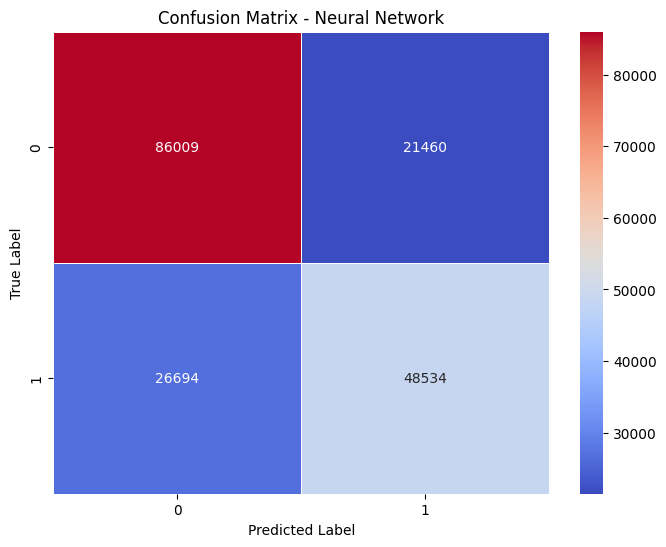

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred_probs = model_1993.predict(X_test_1993)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test_1993, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d', linewidths=0.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural Network")
plt.show()

In [22]:
model_1993.save("1993_model.h5")